Illustration of preprocessing on tracts

In [105]:
import numpy as np
from dipy.io.streamline import load_tractogram
from coloraide import Color
import matplotlib.pylab as pl

In [106]:
path='/home/gui/Documents/Post-doc/data/HCP_105/'

# 22 Align

(-40.0, 80.0)

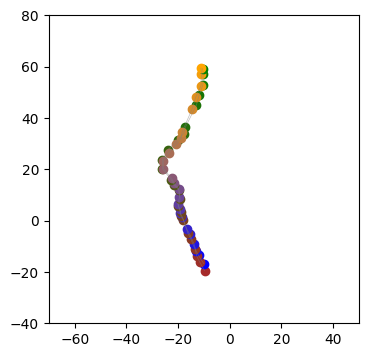

In [25]:
tract1 = load_tractogram(
            path+'599469/05-Tracts/trk/CST_left.trk', 
            reference='same')

tract2 = load_tractogram(
            path+'599469/05-Tracts/2aligned_CST_left.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

m1,m2=tract1.streamlines[0],tract2.streamlines[0]
nb_pts=m1.shape[0]

s=5e-1
axis=(0,2)
cmap1 = Color.interpolate(["brown", "green"],space='srgb')
cmap2 = Color.interpolate(["blue", "orange"],space='srgb')
pl.figure(figsize=(4,4))
for i in range(nb_pts):
    color1=cmap1(i/(nb_pts-1))
    color2=cmap2(i/(nb_pts-1))
    pl.scatter(m1[i,axis[0]], m1[i,axis[1]],color=color1)
    pl.scatter(m2[i,axis[0]], m2[i,axis[1]],color=color2)
pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

# 23 Reordering

(-40.0, 80.0)

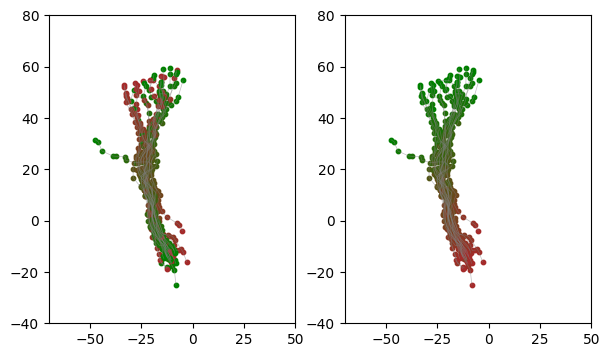

In [29]:
tract1 = load_tractogram(
            path+'599469/05-Tracts/2aligned_CST_left.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

tract2 = load_tractogram(
            path+'599469/05-Tracts/3reordered_CST_left.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')


nb_streamline=20

s=1e1
axis=(0,2)
cmap1 = Color.interpolate(["brown", "green"],space='srgb')
pl.figure(figsize=(7,4))
pl.subplot(1,2,1)
for j in range(nb_streamline):
    m1=tract1.streamlines[j]
    nb_pts=m1.shape[0]
    for i in range(nb_pts):
        color1=cmap1(i/(nb_pts-1))
        pl.scatter(m1[i,axis[0]], m1[i,axis[1]],color=color1,s=s)
    pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

pl.subplot(1,2,2)
for j in range(nb_streamline):
    m2=tract2.streamlines[j]
    nb_pts=m2.shape[0]
    for i in range(nb_pts):
        color1=cmap1(i/(nb_pts-1))
        pl.scatter(m2[i,axis[0]], m2[i,axis[1]],color=color1,s=s)
    pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

# 24 Newgrid

(-40.0, 80.0)

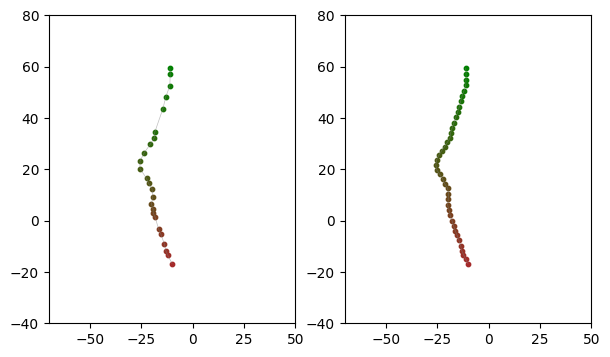

In [32]:
tract1 = load_tractogram(
            path+'599469/05-Tracts/3reordered_CST_left.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

tract2 = load_tractogram(
            path+'599469/05-Tracts/4newgrid_CST_left_n40.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')


m1,m2=tract1.streamlines[0],tract2.streamlines[0]
nb_pts1,nb_pts2=m1.shape[0],m2.shape[0]

s=1e1
axis=(0,2)
cmap1 = Color.interpolate(["brown", "green"],space='srgb')
pl.figure(figsize=(7,4))
pl.subplot(1,2,1)
for i in range(nb_pts1):
    color1=cmap1(i/(nb_pts1-1))
    pl.scatter(m1[i,axis[0]], m1[i,axis[1]],color=color1,s=s)
pl.plot(m1[:,axis[0]], m1[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

pl.subplot(1,2,2)
for i in range(nb_pts2):
    color1=cmap1(i/(nb_pts2-1))
    pl.scatter(m2[i,axis[0]], m2[i,axis[1]],color=color1,s=s)
pl.plot(m2[:,axis[0]], m2[:,axis[1]],linewidth=.5,color='grey',alpha=.5)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

# 251 Clustering

12426 1000


(-40.0, 80.0)

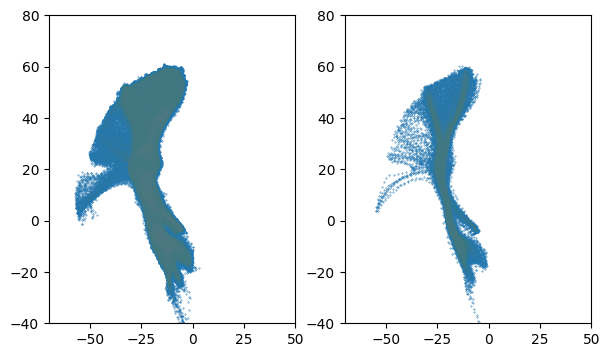

In [91]:
import sys
sys.path.append('script/')
from from_vtk_to_numpy import vtk_to_numpy_tract_array

tract1 = load_tractogram(
            path+'599469/05-Tracts/4newgrid_CST_left_n40.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

tract2 = load_tractogram(
            path+'599469/05-Tracts/51clustered_CST_left_n40_s1000.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

nb_streamline1,nb_streamline2=len(tract1.streamlines),len(tract2.streamlines)
print(nb_streamline1,nb_streamline2)
m1=vtk_to_numpy_tract_array(tract1,nb_streamline1)[0]
m2=vtk_to_numpy_tract_array(tract2,nb_streamline2)[0]

s=1e-1
axis=(0,2)
color='C0'
pl.figure(figsize=(7,4))
pl.subplot(1,2,1)
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

pl.subplot(1,2,2)
pl.scatter(m2[:,:,axis[0]], m2[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline2):
    pl.plot(m2[i,:,axis[0]], m2[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

# 252 Downsampling

12426 966


(-40.0, 80.0)

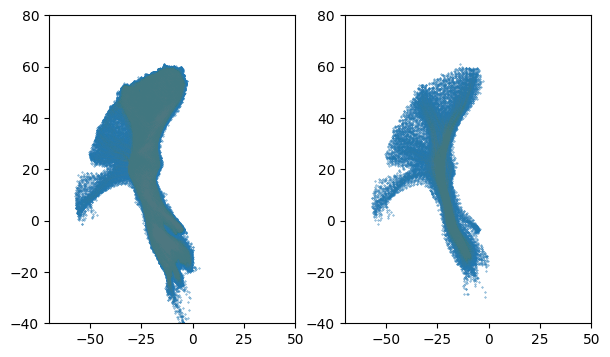

In [108]:
import sys
sys.path.append('script/')
from from_vtk_to_numpy import vtk_to_numpy_tract_array

tract1 = load_tractogram(
            path+'599469/05-Tracts/4newgrid_CST_left_n40.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

tract2 = load_tractogram(
            path+'599469/05-Tracts/52downsampled_CST_left_n40_c30.vtk', 
            reference=path+'000000/02-TransfoToMNISpace/averageDTI.nii.gz')

nb_streamline1,nb_streamline2=len(tract1.streamlines),len(tract2.streamlines)
print(nb_streamline1,nb_streamline2)
m1=vtk_to_numpy_tract_array(tract1,nb_streamline1)[0]
m2=vtk_to_numpy_tract_array(tract2,nb_streamline2)[0]

s=1e-1
axis=(0,2)
color='C0'
pl.figure(figsize=(7,4))
pl.subplot(1,2,1)
pl.scatter(m1[:,:,axis[0]], m1[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline1):
    pl.plot(m1[i,:,axis[0]], m1[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)

pl.subplot(1,2,2)
pl.scatter(m2[:,:,axis[0]], m2[:,:,axis[1]],color=color,s=s)
for i in range(nb_streamline2):
    pl.plot(m2[i,:,axis[0]], m2[i,:,axis[1]],linewidth=.1,color='grey',alpha=.1)
xmin,ymin,sq=-70,-40,120
pl.xlim(xmin,xmin+sq)
pl.ylim(ymin,ymin+sq)